In [63]:
import pandas as pd
import numpy as np
import seaborn as sns

In [64]:
import os

os.listdir('/content')

['.config',
 'label_encoder.pkl',
 'toxic_comments_processed.csv',
 'drive',
 'tfidf_vectorizer.pkl',
 'toxicity_model.pkl',
 'toxic_comments_dataset.csv',
 'sample_data']

In [65]:
# Cell 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For text processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

# For visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab') # Added to download the missing resource

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [66]:
df = pd.read_csv("/content/toxic_comments_dataset.csv")

In [67]:
from google.colab import files

# Run this cell to open a file selection dialog
# uploaded = files.upload()

# # To see the uploaded file(s) and their content (optional)
# for fn in uploaded.keys():
#   print('User uploaded file "{name}" with length {length} bytes'.format(
#       name=fn, length=len(uploaded[fn])))


In [68]:
# Cell 2: Load the dataset
# Read the CSV file
df = pd.read_csv("/content/toxic_comments_dataset.csv")

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (30000, 15)

First 5 rows:


,Comment_ID,Comment_Text,Toxicity_Label,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count,Platform,Topic,Moderation_Priority,Language
0,COM000001,The message targets a group unfairly and viola...,Identity_Attack,0,1,0,0,1,0.818,66,10,Community Chat,Sports,High,English
1,COM000002,Thank you for sharing this perspective with th...,Clean,1,0,0,0,0,0.069,58,9,News Comments,Entertainment,High,English
2,COM000003,That response is aggressive and not helpful.,Toxic,0,1,0,0,0,0.622,44,7,Social Media,Politics,Low,English
3,COM000004,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.010,61,9,Social Media,Entertainment,Low,English
4,COM000005,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.140,52,8,Blog,Sports,Low,English


In [69]:
# Cell 3: Basic dataset information
print("=== Dataset Information ===")
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMemory Usage:")
print(df.info(memory_usage='deep'))

print("\nBasic Statistics:")
df.describe()

=== Dataset Information ===

Column Names:
['Comment_ID', 'Comment_Text', 'Toxicity_Label', 'Clean', 'Toxic', 'Severe_Toxic', 'Threat', 'Identity_Attack', 'Toxicity_Score', 'Comment_Length', 'Word_Count', 'Platform', 'Topic', 'Moderation_Priority', 'Language']

Data Types:
Comment_ID              object
Comment_Text            object
Toxicity_Label          object
Clean                    int64
Toxic                    int64
Severe_Toxic             int64
Threat                   int64
Identity_Attack          int64
Toxicity_Score         float64
Comment_Length           int64
Word_Count               int64
Platform                object
Topic                   object
Moderation_Priority     object
Language                object
dtype: object

Memory Usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Comment_ID        

,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.619300,0.380700,0.060033,0.048633,0.048933,0.324542,56.357633,8.340633
std,0.485567,0.485567,0.237553,0.215104,0.215732,0.302914,6.962596,0.972094
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,39.000000,6.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.079000,52.000000,8.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.161000,58.000000,8.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.624000,61.000000,9.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.950000,71.000000,11.000000


In [70]:
# Cell 4: Check for missing values
print("=== Missing Values ===")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percentage': missing_percentage
})
print(missing_df[missing_df['Missing_Count'] > 0])

=== Missing Values ===
Empty DataFrame
Columns: [Missing_Count, Missing_Percentage]
Index: []


In [71]:
# Cell 5: Check for duplicates
print("=== Duplicate Check ===")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print("Duplicate rows found. We'll handle them in preprocessing.")

=== Duplicate Check ===
Number of duplicate rows: 0


In [72]:
# Cell 6: Data types and unique values analysis
print("=== Column Analysis ===")
for col in df.columns:
    print(f"\nColumn: {col}")
    print(f"  Data Type: {df[col].dtype}")
    print(f"  Unique Values: {df[col].nunique()}")
    if df[col].dtype == 'object' and df[col].nunique() < 20:
        print(f"  Value Counts:\n{df[col].value_counts()}")

=== Column Analysis ===

Column: Comment_ID
  Data Type: object
  Unique Values: 30000

Column: Comment_Text
  Data Type: object
  Unique Values: 17
  Value Counts:
Comment_Text
This article provides useful information and clear examples.               4685
Thank you for sharing this perspective with the community.                 4681
I respectfully disagree but I understand your point.                       4659
I appreciate your explanation and the discussion was helpful.              4554
The tone of this message is toxic and inappropriate.                       1721
That response is aggressive and not helpful.                               1703
Your message is unnecessarily hostile and offensive.                       1646
This comment is rude and disrespectful.                                    1623
This message contains severe abusive language and should be removed.        620
The comment is extremely hostile and violates community standards.          593
This reply includes in

=== Toxicity Label Distribution ===
Toxicity_Label
Clean              18579
Toxic               6693
Severe_Toxic        1801
Identity_Attack     1468
Threat              1459
Name: count, dtype: int64


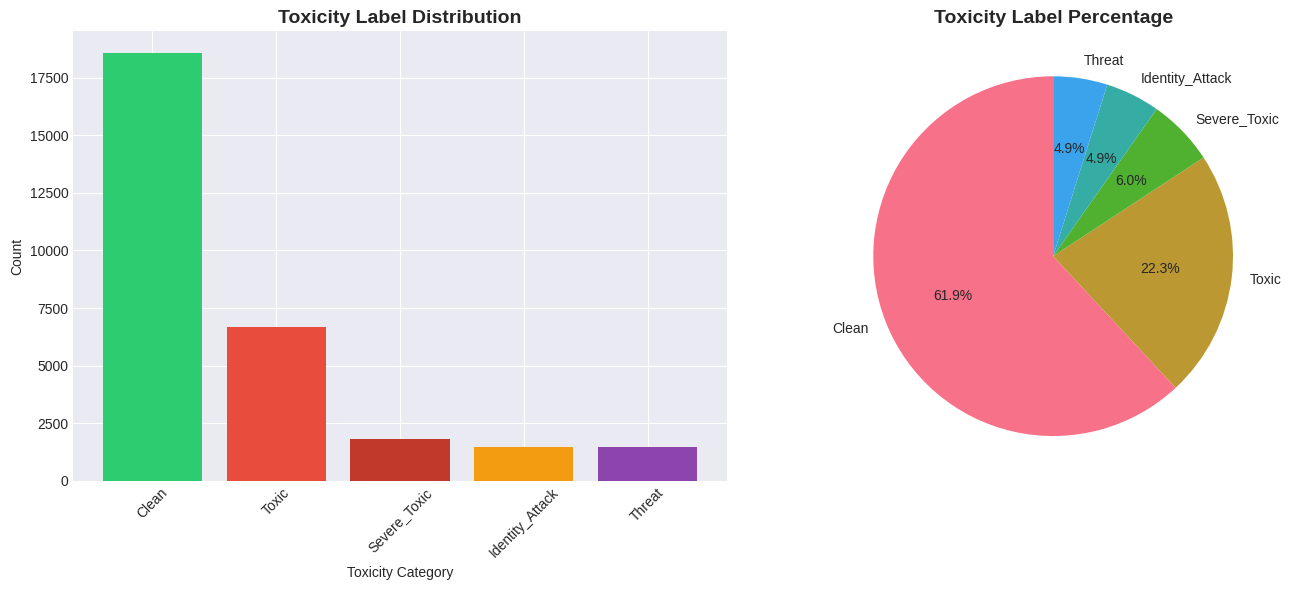


Class Imbalance Ratio:
Clean: 61.93%
Toxic: 22.31%
Severe_Toxic: 6.00%
Identity_Attack: 4.89%
Threat: 4.86%


In [73]:
# Cell 7: Target variable distribution
print("=== Toxicity Label Distribution ===")
toxicity_counts = df['Toxicity_Label'].value_counts()
print(toxicity_counts)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot
axes[0].bar(toxicity_counts.index, toxicity_counts.values,
            color=['#2ecc71', '#e74c3c', '#c0392b', '#f39c12', '#8e44ad'])
axes[0].set_title('Toxicity Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Toxicity Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(toxicity_counts.values, labels=toxicity_counts.index,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Toxicity Label Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Class imbalance check
print("\nClass Imbalance Ratio:")
for label, count in toxicity_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{label}: {percentage:.2f}%")

=== Binary Label Analysis ===
Clean: 18579 (61.93%)
Toxic: 11421 (38.07%)
Severe_Toxic: 1801 (6.00%)
Threat: 1459 (4.86%)
Identity_Attack: 1468 (4.89%)


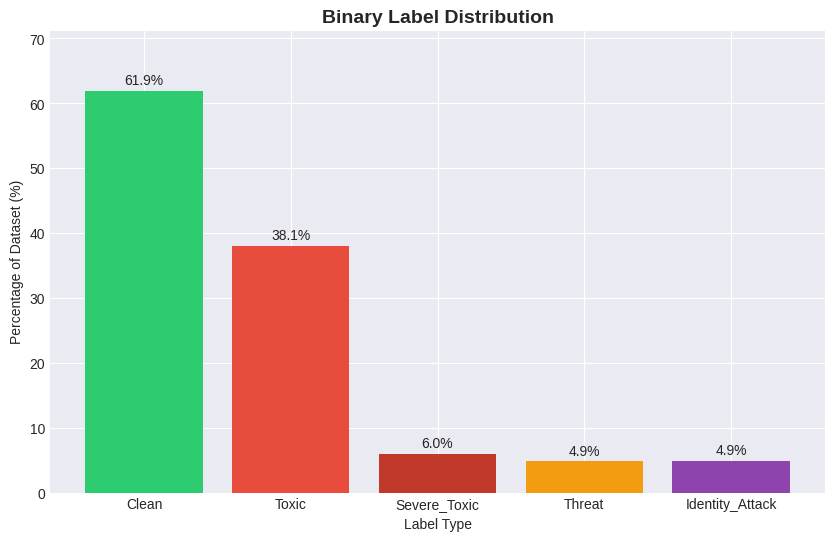

In [74]:
# Cell 8: Binary label analysis
print("=== Binary Label Analysis ===")
binary_columns = ['Clean', 'Toxic', 'Severe_Toxic', 'Threat', 'Identity_Attack']

binary_stats = {}
for col in binary_columns:
    if col in df.columns:
        positive_count = df[col].sum()
        percentage = (positive_count / len(df)) * 100
        binary_stats[col] = {'Count': positive_count, 'Percentage': percentage}
        print(f"{col}: {positive_count} ({percentage:.2f}%)")

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71', '#e74c3c', '#c0392b', '#f39c12', '#8e44ad']

ax.bar(binary_stats.keys(), [v['Percentage'] for v in binary_stats.values()], color=colors)
ax.set_title('Binary Label Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Label Type')
ax.set_ylabel('Percentage of Dataset (%)')
ax.set_ylim(0, max([v['Percentage'] for v in binary_stats.values()]) * 1.15)

# Add percentage labels on bars
for i, (key, value) in enumerate(binary_stats.items()):
    ax.text(i, value['Percentage'] + 0.5, f"{value['Percentage']:.1f}%",
            ha='center', va='bottom')

plt.show()

=== Comment Text Statistics ===
         word_count    char_count  avg_word_length
count  30000.000000  30000.000000     30000.000000
mean       8.340633     56.357633         6.767231
std        0.972094      6.962596         0.495295
min        6.000000     39.000000         5.777778
25%        8.000000     52.000000         6.444444
50%        8.000000     58.000000         6.500000
75%        9.000000     61.000000         7.333333
max       11.000000     71.000000         7.625000


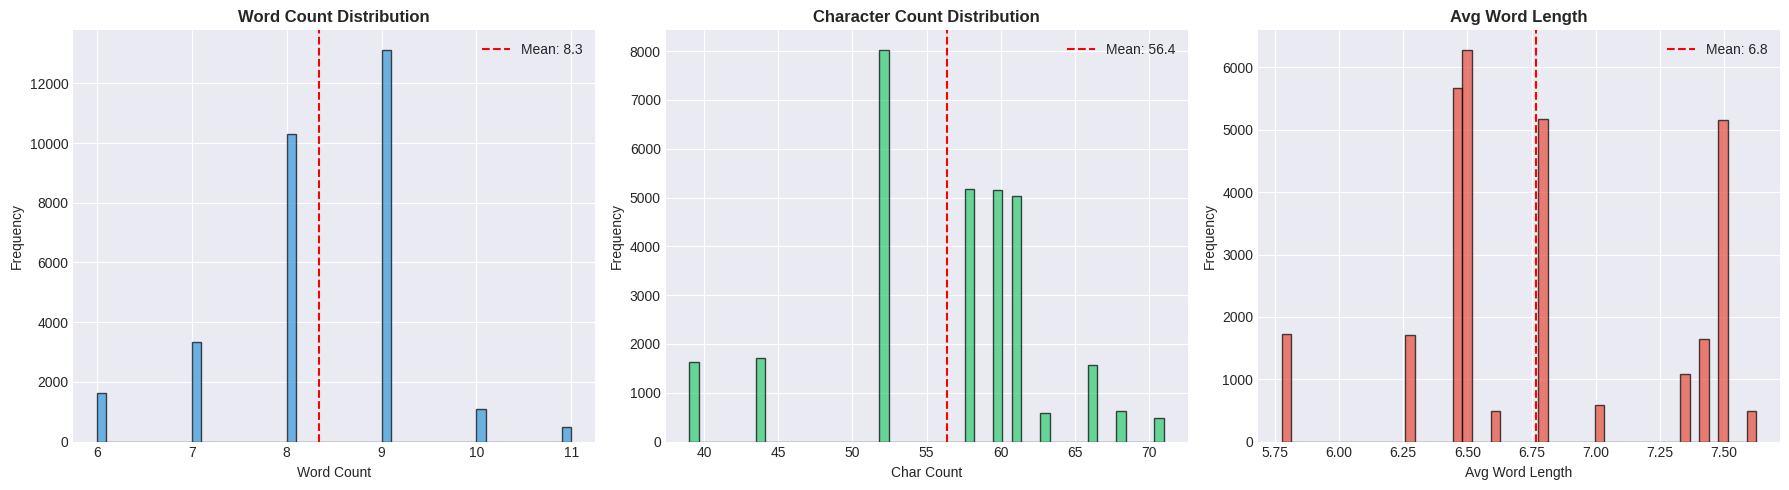

In [75]:
# Cell 9: Comment length analysis
def get_text_stats(text):
    """Calculate various statistics for a text"""
    words = str(text).split()
    chars = len(str(text))
    return {
        'word_count': len(words),
        'char_count': chars,
        'avg_word_length': chars / len(words) if len(words) > 0 else 0
    }

# Apply to comments
text_stats = df['Comment_Text'].apply(get_text_stats)
df_stats = pd.DataFrame(text_stats.tolist())

print("=== Comment Text Statistics ===")
print(df_stats.describe())

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

stats = ['word_count', 'char_count', 'avg_word_length']
titles = ['Word Count Distribution', 'Character Count Distribution', 'Avg Word Length']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (stat, title, color) in enumerate(zip(stats, titles, colors)):
    axes[i].hist(df_stats[stat], bins=50, color=color, alpha=0.7, edgecolor='black')
    axes[i].axvline(df_stats[stat].mean(), color='red', linestyle='--',
                    label=f'Mean: {df_stats[stat].mean():.1f}')
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(stat.replace('_', ' ').title())
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.show()

=== Text Length by Toxicity Category ===

Identity_Attack:
  Mean: 9.7
  Median: 10.0
  Std: 1.2
  Min: 8.0
  Max: 11.0

Clean:
  Mean: 8.5
  Median: 8.0
  Std: 0.5
  Min: 8.0
  Max: 9.0

Toxic:
  Mean: 7.3
  Median: 7.0
  Std: 1.1
  Min: 6.0
  Max: 9.0

Threat:
  Mean: 8.7
  Median: 9.0
  Std: 0.5
  Min: 8.0
  Max: 9.0

Severe_Toxic:
  Mean: 9.3
  Median: 9.0
  Std: 0.5
  Min: 9.0
  Max: 10.0


<Figure size 1200x600 with 0 Axes>

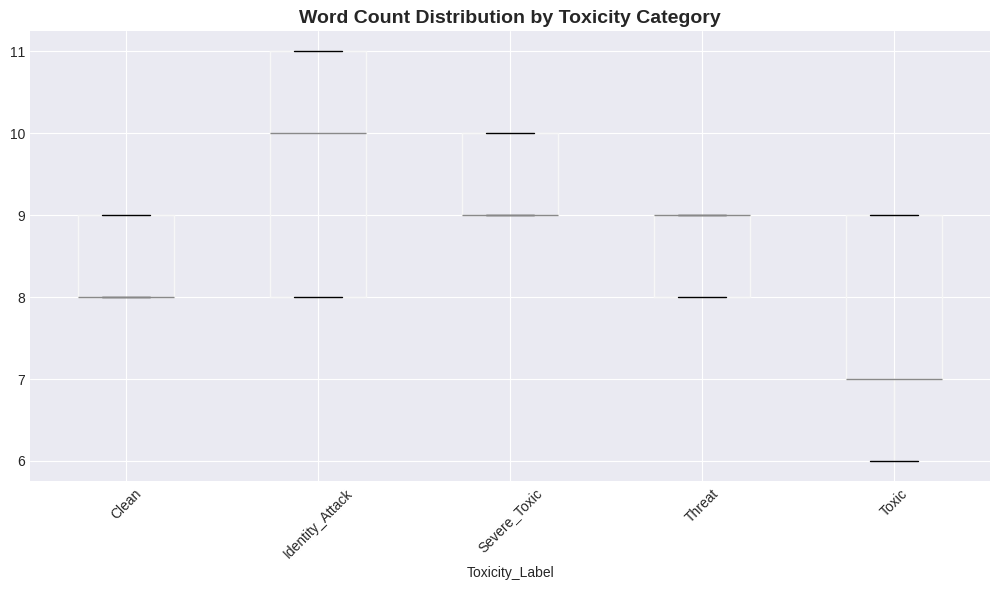

In [108]:
# Cell 10: Length analysis by toxicity category
print("=== Text Length by Toxicity Category ===")
df['Word_Count'] = df_stats['word_count']

for label in df['Toxicity_Label'].unique():
    category_data = df[df['Toxicity_Label'] == label]
    stats = category_data['Word_Count'].describe()
    print(f"\n{label}:")
    print(f"  Mean: {stats['mean']:.1f}")
    print(f"  Median: {stats['50%']:.1f}")
    print(f"  Std: {stats['std']:.1f}")
    print(f"  Min: {stats['min']:.1f}")
    print(f"  Max: {stats['max']:.1f}")

# Boxplot visualization
plt.figure(figsize=(12, 6))
df.boxplot(column='Word_Count', by='Toxicity_Label', figsize=(12, 6))
plt.title('Word Count Distribution by Toxicity Category', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xticks(rotation=45)
plt.show()

=== Platform Analysis ===
Platform
Community Chat    6078
News Comments     6058
Blog              5971
Social Media      5967
Forum             5926
Name: count, dtype: int64


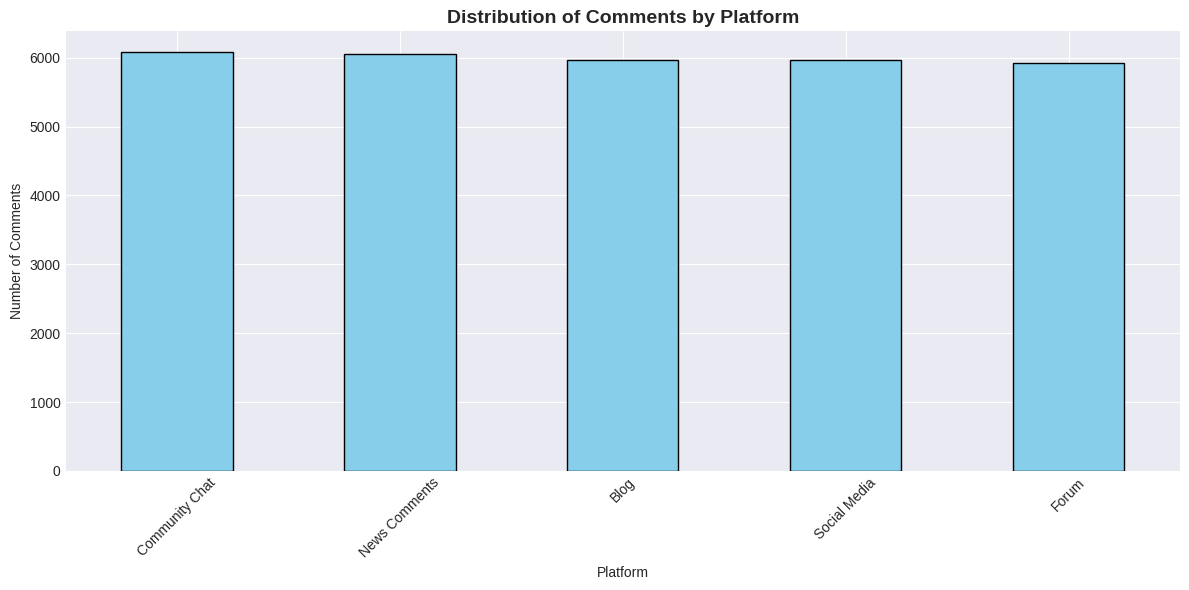

In [107]:
# Cell 11: Platform analysis
if 'Platform' in df.columns:
    print("=== Platform Analysis ===")
    platform_counts = df['Platform'].value_counts()
    print(platform_counts)

    plt.figure(figsize=(12, 6))
    platform_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Distribution of Comments by Platform', fontsize=14, fontweight='bold')
    plt.xlabel('Platform')
    plt.ylabel('Number of Comments')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

=== Topic Analysis ===
Topic
Technology       5105
Education        5052
Gaming           5021
Politics         4987
Sports           4964
Entertainment    4871
Name: count, dtype: int64


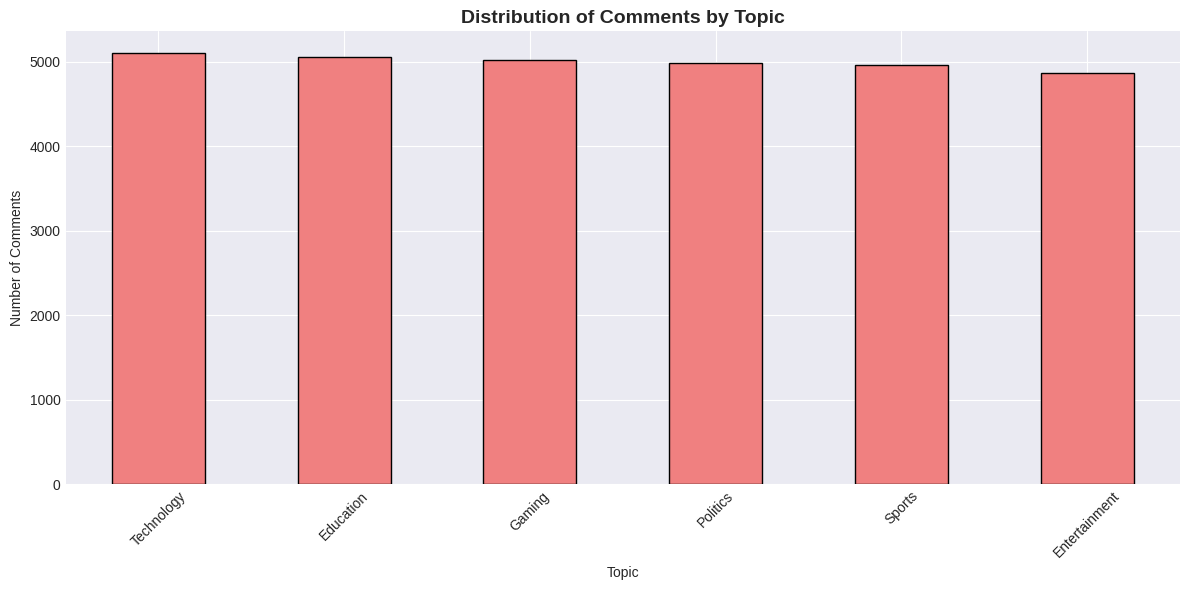

In [109]:
# Cell 12: Topic analysis
if 'Topic' in df.columns:
    print("=== Topic Analysis ===")
    topic_counts = df['Topic'].value_counts()
    print(topic_counts)

    plt.figure(figsize=(12, 6))
    topic_counts.plot(kind='bar', color='lightcoral', edgecolor='black')
    plt.title('Distribution of Comments by Topic', fontsize=14, fontweight='bold')
    plt.xlabel('Topic')
    plt.ylabel('Number of Comments')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

=== Toxicity Distribution by Platform ===
Toxicity_Label      Clean  Identity_Attack  Severe_Toxic    Threat      Toxic
Platform                                                                     
Blog            62.150394         4.521856      5.710936  5.041032  22.575783
Community Chat  62.207963         4.837117      5.955907  4.738401  22.260612
Forum           62.065474         5.163685      6.378670  4.792440  21.599730
News Comments   61.654011         4.803566      5.843513  4.820073  22.878838
Social Media    61.571979         5.144964      6.133736  4.927099  22.222222


<Figure size 1400x800 with 0 Axes>

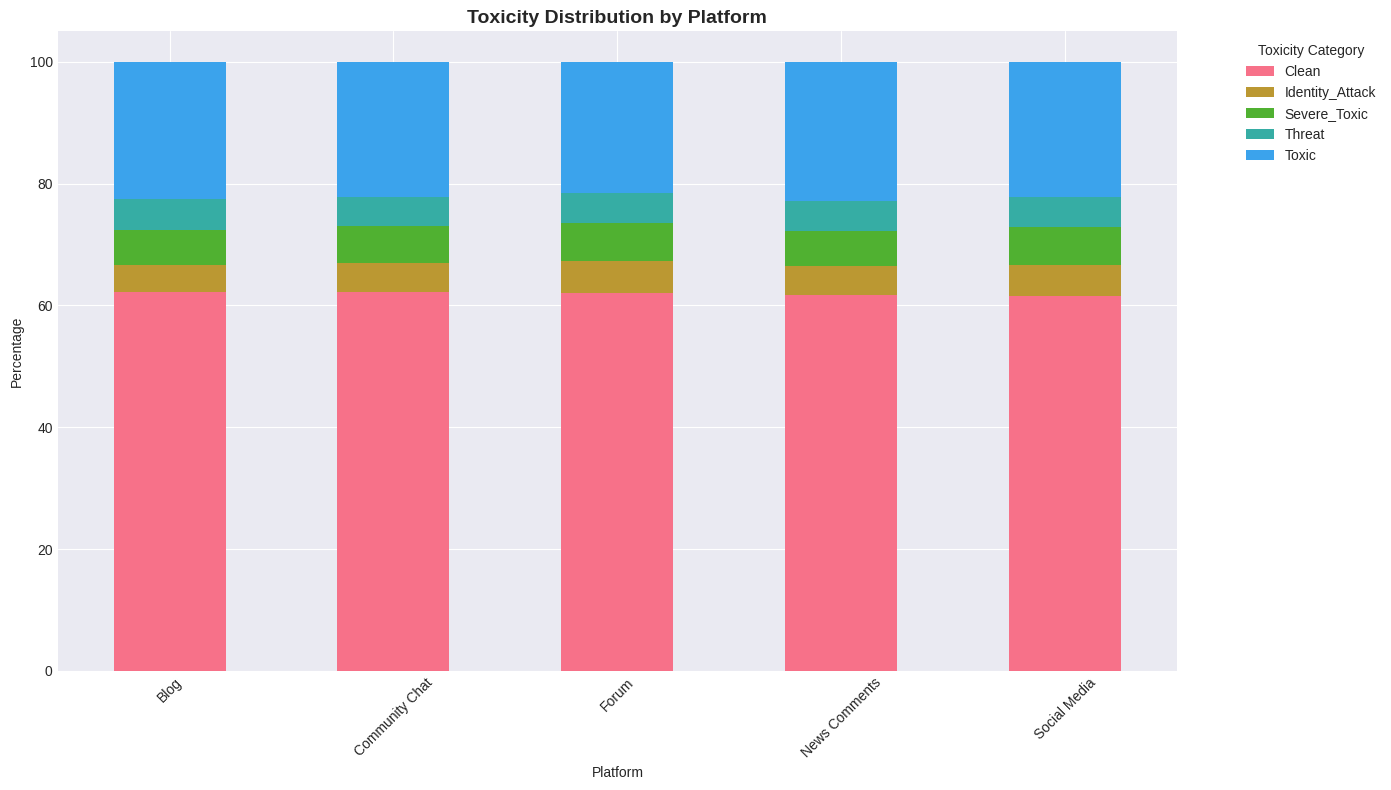

In [106]:
# Cell 13: Cross-analysis - Toxicity by Platform
if 'Platform' in df.columns and 'Toxicity_Label' in df.columns:
    print("=== Toxicity Distribution by Platform ===")
    cross_tab = pd.crosstab(df['Platform'], df['Toxicity_Label'], normalize='index') * 100
    print(cross_tab)

    plt.figure(figsize=(14, 8))
    cross_tab.plot(kind='bar', stacked=True, figsize=(14, 8))
    plt.title('Toxicity Distribution by Platform', fontsize=14, fontweight='bold')
    plt.xlabel('Platform')
    plt.ylabel('Percentage')
    plt.legend(title='Toxicity Category', bbox_to_anchor=(1.05, 1))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

=== Correlation Matrix ===


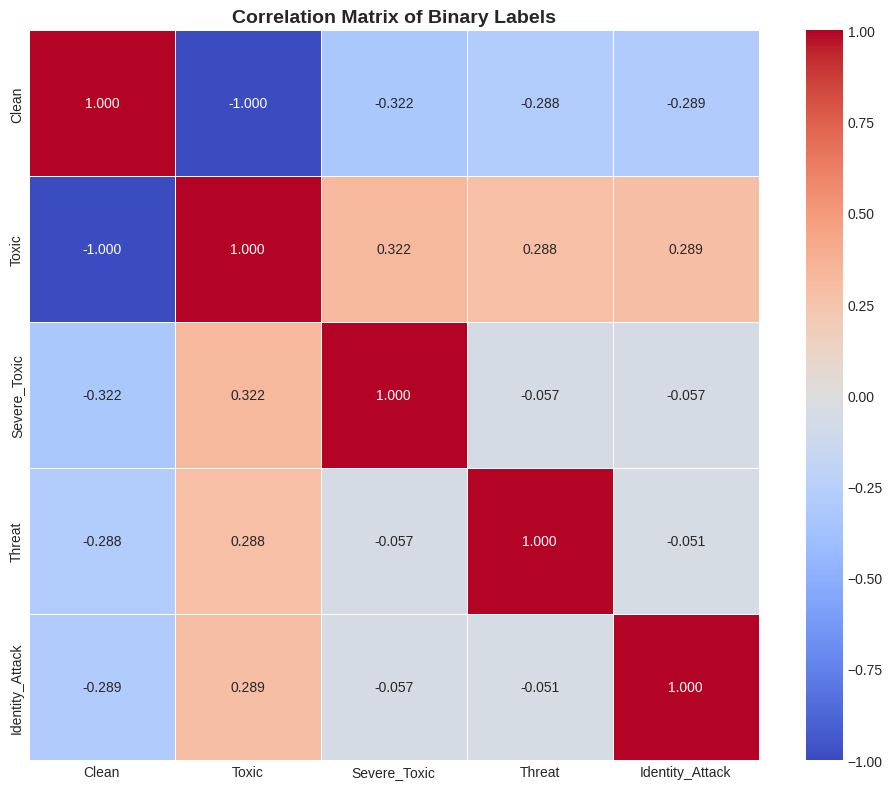

In [105]:
# Cell 14: Correlation matrix for binary labels
if all(col in df.columns for col in binary_columns):
    print("=== Correlation Matrix ===")
    corr_matrix = df[binary_columns].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, fmt='.3f')
    plt.title('Correlation Matrix of Binary Labels', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [104]:
# Cell 15: Text Preprocessing Functions
def clean_text(text):
    """Clean and preprocess text"""
    if pd.isna(text):
        return ""

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags but keep the word
    text = re.sub(r'#(\w+)', r'\1', text)

    # Remove special characters and digits (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def tokenize_and_lemmatize(text):
    """Tokenize and lemmatize text"""
    # Tokenize
    tokens = nltk.word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]

    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return tokens

print("Text preprocessing functions defined!")

Text preprocessing functions defined!


In [103]:
# Cell 16: Apply text preprocessing
print("=== Preprocessing Comments ===")

# Create a copy of the dataset
df_processed = df.copy()

# Apply cleaning
print("Cleaning text...")
df_processed['Cleaned_Comment'] = df_processed['Comment_Text'].apply(clean_text)

# Tokenize and lemmatize
print("Tokenizing and lemmatizing...")
df_processed['Tokens'] = df_processed['Cleaned_Comment'].apply(tokenize_and_lemmatize)

# Create cleaned text (joined tokens)
df_processed['Processed_Comment'] = df_processed['Tokens'].apply(lambda x: ' '.join(x))

print("Text preprocessing complete!")
print(f"Sample: {df_processed['Processed_Comment'][0][:100]}...")

=== Preprocessing Comments ===
Cleaning text...
Tokenizing and lemmatizing...
Text preprocessing complete!
Sample: message target group unfairly violates community rule...


In [102]:
# Cell 17: Compare before and after preprocessing
print("=== Before and After Comparison ===")
sample_idx = 0
print(f"Original: {df_processed['Comment_Text'][sample_idx][:200]}")
print(f"Cleaned: {df_processed['Cleaned_Comment'][sample_idx][:200]}")
print(f"Processed: {df_processed['Processed_Comment'][sample_idx][:200]}")

=== Before and After Comparison ===
Original: The message targets a group unfairly and violates community rules.
Cleaned: the message targets a group unfairly and violates community rules
Processed: message target group unfairly violates community rule


=== Most Common Words ===


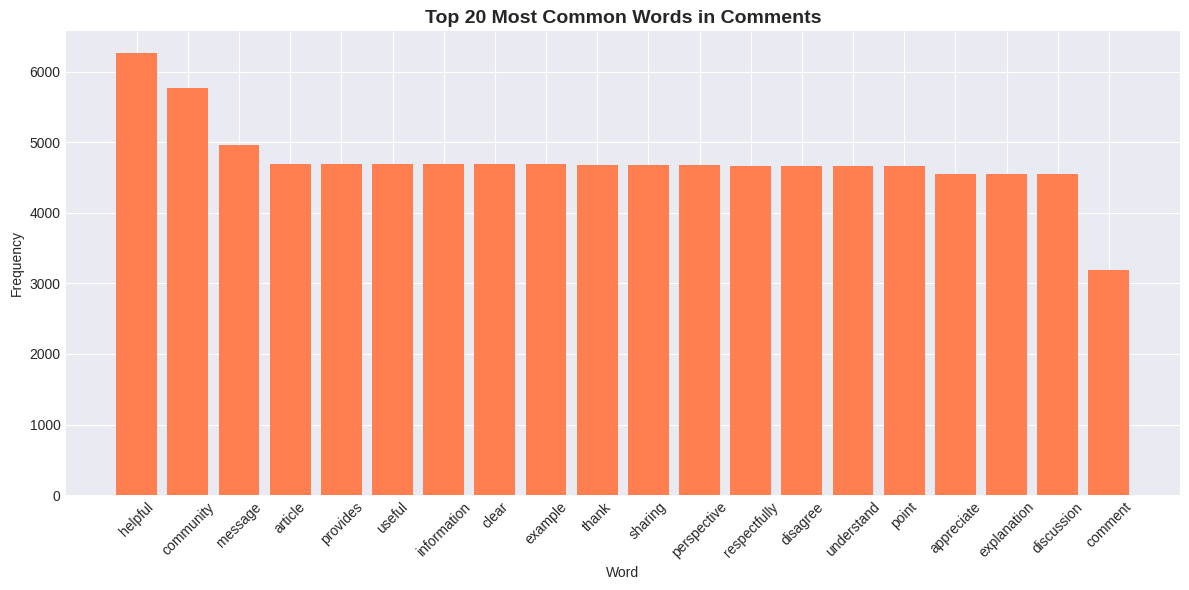

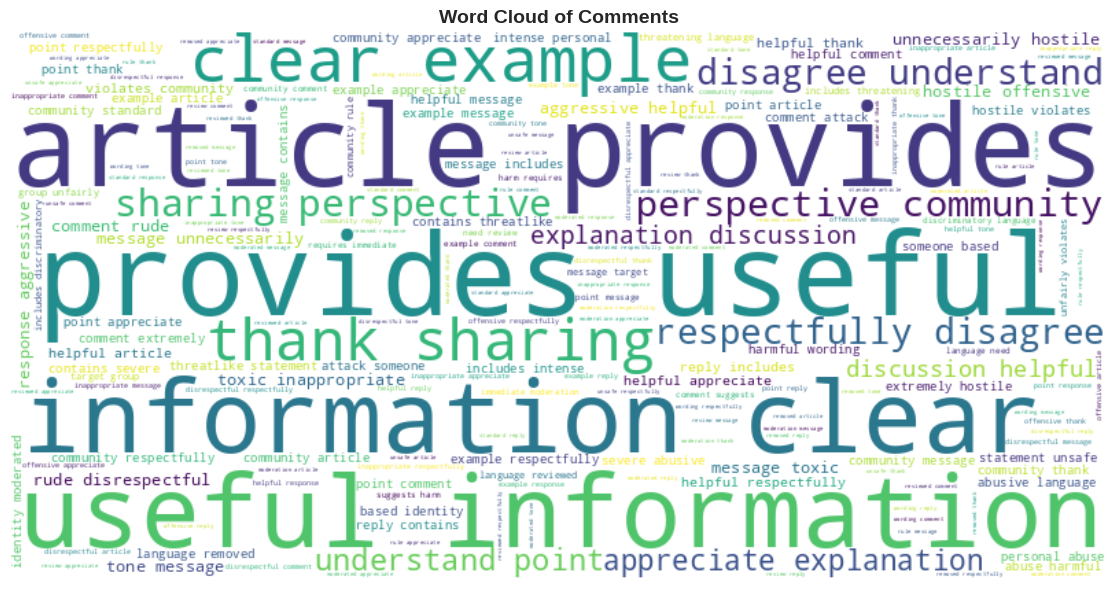

In [101]:
# Cell 18: Most common words analysis
print("=== Most Common Words ===")
all_tokens = [token for tokens in df_processed['Tokens'] for token in tokens]
word_freq = Counter(all_tokens)

# Top 20 words
top_words = word_freq.most_common(20)
top_words_df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])

plt.figure(figsize=(12, 6))
plt.bar(top_words_df['Word'], top_words_df['Frequency'], color='coral')
plt.title('Top 20 Most Common Words in Comments', fontsize=14, fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Word cloud (optional - requires wordcloud package)
try:
    from wordcloud import WordCloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_tokens))
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Comments', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
except ImportError:
    print("WordCloud package not installed. Skipping word cloud generation.")
    print("To install: pip install wordcloud")

In [110]:
# Cell 19: Additional Features
print("=== Feature Engineering ===")

# Add text length features
df_processed['Comment_Length'] = df_processed['Comment_Text'].str.len()
df_processed['Processed_Length'] = df_processed['Cleaned_Comment'].str.len()
df_processed['Token_Count'] = df_processed['Tokens'].str.len()

# Add punctuation and special character counts
df_processed['Exclamation_Count'] = df_processed['Comment_Text'].str.count('!')
df_processed['Question_Count'] = df_processed['Comment_Text'].str.count('\?')
df_processed['Upper_Count'] = df_processed['Comment_Text'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))

# Add sentiment features (if needed - using TextBlob)
try:
    from textblob import TextBlob
    df_processed['Sentiment_Polarity'] = df_processed['Comment_Text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
    df_processed['Sentiment_Subjectivity'] = df_processed['Comment_Text'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)
    print("Sentiment features added!")
except ImportError:
    print("TextBlob not installed. Skipping sentiment features.")
    print("To install: pip install textblob")

print("\nNew features created:")
new_features = [col for col in df_processed.columns if col not in df.columns]
print(f"Added features: {new_features}")

=== Feature Engineering ===
Sentiment features added!

New features created:
Added features: ['Cleaned_Comment', 'Tokens', 'Processed_Comment', 'Processed_Length', 'Token_Count', 'Exclamation_Count', 'Question_Count', 'Upper_Count', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


In [96]:
# Cell 20: Encode target variable
from sklearn.preprocessing import LabelEncoder

print("=== Encoding Labels ===")
# Encode Toxicity_Label
label_encoder = LabelEncoder()
df_processed['Toxicity_Label_Encoded'] = label_encoder.fit_transform(df_processed['Toxicity_Label'])

# Display mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Encoding Mapping:")
for label, code in label_mapping.items():
    print(f"  {label} -> {code}")

=== Encoding Labels ===
Label Encoding Mapping:
  Clean -> 0
  Identity_Attack -> 1
  Severe_Toxic -> 2
  Threat -> 3
  Toxic -> 4


In [97]:
# Cell 21: Prepare features for ML
print("=== Preparing ML Features ===")

# Select features for ML
ml_features = []

# Add numeric features
numeric_cols = ['Comment_Length', 'Processed_Length', 'Token_Count',
                'Exclamation_Count', 'Question_Count', 'Upper_Count']

if 'Sentiment_Polarity' in df_processed.columns:
    numeric_cols.extend(['Sentiment_Polarity', 'Sentiment_Subjectivity'])

# Add binary labels as features (optional)
binary_features = [col for col in binary_columns if col != 'Clean']

# For multi-class classification, we'll use:
# - Numeric features
# - Binary labels as additional features
# - Processed text for TF-IDF/Word Embeddings

print("Numeric features:", numeric_cols)
print("Binary features:", binary_features)

# Create feature matrix (numeric + binary)
X_numeric = df_processed[numeric_cols + binary_features].copy()
y = df_processed['Toxicity_Label_Encoded']

print(f"\nFeature matrix shape: {X_numeric.shape}")
print(f"Target shape: {y.shape}")

=== Preparing ML Features ===
Numeric features: ['Comment_Length', 'Processed_Length', 'Token_Count', 'Exclamation_Count', 'Question_Count', 'Upper_Count', 'Sentiment_Polarity', 'Sentiment_Subjectivity']
Binary features: ['Toxic', 'Severe_Toxic', 'Threat', 'Identity_Attack']

Feature matrix shape: (30000, 12)
Target shape: (30000,)


In [88]:
# Cell 22: Create TF-IDF features
from sklearn.feature_extraction.text import TfidfVectorizer

print("=== Creating TF-IDF Features ===")

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_tfidf = tfidf_vectorizer.fit_transform(df_processed['Processed_Comment'])

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Number of features: {X_tfidf.shape[1]}")

=== Creating TF-IDF Features ===
TF-IDF matrix shape: (30000, 132)
Number of features: 132


In [98]:
# Cell 23: Split data into train and test sets
from sklearn.model_selection import train_test_split

print("=== Train-Test Split ===")

# Combine features (numeric + binary)
X_numeric_matrix = X_numeric.values

# Split the data
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

X_train_numeric, X_test_numeric, y_train_numeric, y_test_numeric = train_test_split(
    X_numeric_matrix, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set (TF-IDF): {X_train_tfidf.shape}")
print(f"Test set (TF-IDF): {X_test_tfidf.shape}")
print(f"Training set (Numeric): {X_train_numeric.shape}")
print(f"Test set (Numeric): {X_test_numeric.shape}")
print(f"\nTraining target distribution:\n{pd.Series(y_train).value_counts()}")
print(f"\nTest target distribution:\n{pd.Series(y_test).value_counts()}")

=== Train-Test Split ===
Training set (TF-IDF): (24000, 132)
Test set (TF-IDF): (6000, 132)
Training set (Numeric): (24000, 12)
Test set (Numeric): (6000, 12)

Training target distribution:
Toxicity_Label_Encoded
0    14863
4     5354
2     1441
1     1175
3     1167
Name: count, dtype: int64

Test target distribution:
Toxicity_Label_Encoded
0    3716
4    1339
2     360
1     293
3     292
Name: count, dtype: int64


=== Baseline Model Training (TF-IDF) ===
Accuracy: 1.0

Classification Report:
                 precision    recall  f1-score   support

          Clean       1.00      1.00      1.00      3716
Identity_Attack       1.00      1.00      1.00       293
   Severe_Toxic       1.00      1.00      1.00       360
         Threat       1.00      1.00      1.00       292
          Toxic       1.00      1.00      1.00      1339

       accuracy                           1.00      6000
      macro avg       1.00      1.00      1.00      6000
   weighted avg       1.00      1.00      1.00      6000



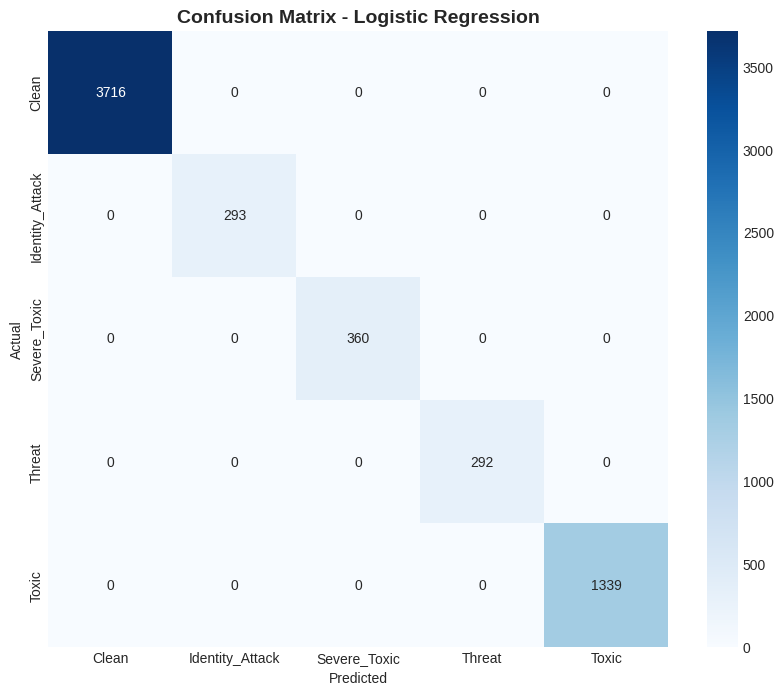

In [90]:
# Cell 24: Train a baseline model (Logistic Regression)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("=== Baseline Model Training (TF-IDF) ===")

# Logistic Regression
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_tfidf, y_train)

# Predictions
y_pred = clf.predict(X_test_tfidf)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [92]:
# Cell 25: Train model with numeric features
print("=== Model Training (Numeric Features) ===")

# Logistic Regression with numeric features
clf_numeric = LogisticRegression(max_iter=1000, random_state=42)
clf_numeric.fit(X_train_numeric, y_train_numeric)

# Predictions
y_pred_numeric = clf_numeric.predict(X_test_numeric)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_numeric))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_numeric, target_names=label_encoder.classes_))

=== Model Training (Numeric Features) ===
Accuracy: 0.9458333333333333

Classification Report:
                 precision    recall  f1-score   support

          Clean       1.00      1.00      1.00      3716
Identity_Attack       0.43      0.32      0.36       293
   Severe_Toxic       0.71      0.65      0.68       360
         Threat       0.74      1.00      0.85       292
          Toxic       1.00      1.00      1.00      1339

       accuracy                           0.95      6000
      macro avg       0.77      0.79      0.78      6000
   weighted avg       0.94      0.95      0.94      6000



In [93]:
# Cell 26: Save preprocessed data
print("=== Saving Preprocessed Data ===")

# Save processed dataset
df_processed.to_csv('toxic_comments_processed.csv', index=False)
print("✓ Processed dataset saved to 'toxic_comments_processed.csv'")

# Save TF-IDF vectorizer
import joblib
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
print("✓ TF-IDF vectorizer saved to 'tfidf_vectorizer.pkl'")

joblib.dump(label_encoder, 'label_encoder.pkl')
print("✓ Label encoder saved to 'label_encoder.pkl'")

# Save the model
joblib.dump(clf, 'toxicity_model.pkl')
print("✓ Model saved to 'toxicity_model.pkl'")

print("\nAll files saved successfully!")

=== Saving Preprocessed Data ===
✓ Processed dataset saved to 'toxic_comments_processed.csv'
✓ TF-IDF vectorizer saved to 'tfidf_vectorizer.pkl'
✓ Label encoder saved to 'label_encoder.pkl'
✓ Model saved to 'toxicity_model.pkl'

All files saved successfully!


In [94]:
# Cell 27: EDA Summary Report
print("="*80)
print("TOXIC COMMENTS DATASET - EDA & PREPROCESSING SUMMARY")
print("="*80)

print(f"\nDataset Name: Toxic Comments Dataset 2026")
print(f"Total Records: {len(df)}")
print(f"Total Features: {len(df.columns)}")

print(f"\nTarget Distribution:")
for label, count in toxicity_counts.items():
    print(f"  {label}: {count} ({count/len(df)*100:.2f}%)")

print(f"\nClass Imbalance: {'Significant' if max(toxicity_counts) / min(toxicity_counts) > 3 else 'Moderate'}")
print(f"Imbalance Ratio: {max(toxicity_counts) / min(toxicity_counts):.2f}")

print(f"\nText Statistics:")
print(f"  Average Comment Length: {df_stats['char_count'].mean():.1f} characters")
print(f"  Average Word Count: {df_stats['word_count'].mean():.1f} words")
print(f"  Average Word Length: {df_stats['avg_word_length'].mean():.1f} characters")

print(f"\nPreprocessing Summary:")
print(f"  - Removed URLs, mentions, special characters")
print(f"  - Applied tokenization and lemmatization")
print(f"  - Added {len(new_features)} engineered features")
print(f"  - Encoded target labels")

print(f"\nModeling Ready:")
print(f"  - TF-IDF features: {X_tfidf.shape[1]} features")
print(f"  - Numeric features: {X_numeric.shape[1]} features")
print(f"  - Train/Test split: 80/20")

print("\n✓ EDA and Preprocessing Complete!")
print("="*80)

TOXIC COMMENTS DATASET - EDA & PREPROCESSING SUMMARY

Dataset Name: Toxic Comments Dataset 2026
Total Records: 30000
Total Features: 15

Target Distribution:
  Clean: 18579 (61.93%)
  Toxic: 6693 (22.31%)
  Severe_Toxic: 1801 (6.00%)
  Identity_Attack: 1468 (4.89%)
  Threat: 1459 (4.86%)

Class Imbalance: Significant
Imbalance Ratio: 12.73

Text Statistics:
  Average Comment Length: 56.4 characters
  Average Word Count: 8.3 words
  Average Word Length: 6.8 characters

Preprocessing Summary:
  - Removed URLs, mentions, special characters
  - Applied tokenization and lemmatization
  - Added 10 engineered features
  - Encoded target labels

Modeling Ready:
  - TF-IDF features: 132 features
  - Numeric features: 8 features
  - Train/Test split: 80/20

✓ EDA and Preprocessing Complete!



MODEL TRAINING
> Add blockquote



In [81]:
# Cell 1: Advanced ML Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, auc, precision_recall_curve
)

# Deep Learning (Optional)
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, GRU, Bidirectional
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    DEEP_LEARNING_AVAILABLE = True
    print("TensorFlow/Keras available for deep learning!")
except ImportError:
    DEEP_LEARNING_AVAILABLE = False
    print("TensorFlow not installed. Deep learning models will be skipped.")

# XGBoost
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("XGBoost available!")
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost not installed. Will be skipped.")

# LightGBM
try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
    print("LightGBM available!")
except ImportError:
    LGB_AVAILABLE = False
    print("LightGBM not installed. Will be skipped.")

import joblib
import os
from datetime import datetime

print("\nAll libraries loaded successfully!")

TensorFlow/Keras available for deep learning!
XGBoost available!
LightGBM available!

All libraries loaded successfully!


In [80]:
# Cell 3: Prepare all feature sets
print("=== Preparing Feature Matrices ===")

# 1. TF-IDF Features
X_tfidf = tfidf_vectorizer.transform(df_processed['Processed_Comment'])
print(f"TF-IDF matrix: {X_tfidf.shape}")

# 2. Numeric Features
numeric_features = ['Comment_Length', 'Processed_Length', 'Token_Count',
                   'Exclamation_Count', 'Question_Count', 'Upper_Count']

# Check if sentiment features exist
sentiment_features = ['Sentiment_Polarity', 'Sentiment_Subjectivity']
for feat in sentiment_features:
    if feat in df_processed.columns:
        numeric_features.append(feat)

X_numeric = df_processed[numeric_features].values
print(f"Numeric features: {X_numeric.shape}")

# 3. Binary Label Features (excluding Clean)
binary_features = ['Toxic', 'Severe_Toxic', 'Threat', 'Identity_Attack']
X_binary = df_processed[binary_features].values
print(f"Binary features: {X_binary.shape}")

# 4. Combine all features
X_combined = np.hstack([X_tfidf.toarray(), X_numeric, X_binary])
print(f"Combined features: {X_combined.shape}")

# 5. Target variable
y = df_processed['Toxicity_Label_Encoded'].values
print(f"Target shape: {y.shape}")

# Display class distribution
unique, counts = np.unique(y, return_counts=True)
print("\nClass distribution:")
for label, count in zip(unique, counts):
    print(f"  {label_encoder.classes_[label]}: {count} ({count/len(y)*100:.2f}%)")

=== Preparing Feature Matrices ===
TF-IDF matrix: (30000, 132)
Numeric features: (30000, 8)
Binary features: (30000, 4)
Combined features: (30000, 144)
Target shape: (30000,)

Class distribution:
  Clean: 18579 (61.93%)
  Identity_Attack: 1468 (4.89%)
  Severe_Toxic: 1801 (6.00%)
  Threat: 1459 (4.86%)
  Toxic: 6693 (22.31%)


In [77]:
# Cell 4: Split data into train and test sets
from sklearn.model_selection import train_test_split

print("=== Train-Test Split ===")
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Split all feature sets
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_train_numeric, X_test_numeric, _, _ = train_test_split(
    X_numeric, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_train_binary, X_test_binary, _, _ = train_test_split(
    X_binary, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_train_combined, X_test_combined, _, _ = train_test_split(
    X_combined, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {len(y_train)}")
print(f"Test set size: {len(y_test)}")
print("\nTraining set distribution:")
train_counts = np.unique(y_train, return_counts=True)
for label, count in zip(train_counts[0], train_counts[1]):
    print(f"  {label_encoder.classes_[label]}: {count} ({count/len(y_train)*100:.2f}%)")

=== Train-Test Split ===
Training set size: 24000
Test set size: 6000

Training set distribution:
  Clean: 14863 (61.93%)
  Identity_Attack: 1175 (4.90%)
  Severe_Toxic: 1441 (6.00%)
  Threat: 1167 (4.86%)
  Toxic: 5354 (22.31%)


In [78]:
# Cell 5: Scale numeric features
from sklearn.preprocessing import StandardScaler

print("=== Feature Scaling ===")

# Scale numeric features
scaler = StandardScaler()
X_train_numeric_scaled = scaler.fit_transform(X_train_numeric)
X_test_numeric_scaled = scaler.transform(X_test_numeric)

# Scale combined features (excluding TF-IDF which is already normalized)
# We need to scale only the numeric and binary parts
scaler_combined = StandardScaler()
X_train_combined_scaled = X_train_combined.copy()
X_test_combined_scaled = X_test_combined.copy()

# Scale numeric + binary parts (last columns)
n_numeric = X_numeric.shape[1]
n_binary = X_binary.shape[1]
n_scaled = n_numeric + n_binary

# Scale the combined features
scaler_combined.fit(X_train_combined[:, -n_scaled:])
X_train_combined_scaled[:, -n_scaled:] = scaler_combined.transform(X_train_combined[:, -n_scaled:])
X_test_combined_scaled[:, -n_scaled:] = scaler_combined.transform(X_test_combined[:, -n_scaled:])

print("✓ Numeric features scaled")
print("✓ Combined features scaled")

=== Feature Scaling ===
✓ Numeric features scaled
✓ Combined features scaled


In [79]:
# Cell 6: Define and evaluate multiple models
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("=== Base Model Evaluation ===")

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'SVM': SVC(random_state=RANDOM_STATE, probability=True)
}

# Add XGBoost if available
if XGB_AVAILABLE:
    models['XGBoost'] = xgb.XGBClassifier(random_state=RANDOM_STATE)

# Add LightGBM if available
if LGB_AVAILABLE:
    models['LightGBM'] = lgb.LGBMClassifier(random_state=RANDOM_STATE)

# Results storage
results = []

print("Training and evaluating models with TF-IDF features...")

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Model: {name}")

    # Train
    model.fit(X_train_tfidf, y_train)

    # Predict
    y_pred = model.predict(X_test_tfidf)
    y_pred_proba = model.predict_proba(X_test_tfidf) if hasattr(model, 'predict_proba') else None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1-Macro': f1_macro,
        'F1-Weighted': f1_weighted
    })

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Macro: {f1_macro:.4f}")
    print(f"  F1-Weighted: {f1_weighted:.4f}")

    # Print classification report
    print("\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Display results summary
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Macro', ascending=False)
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(results_df.to_string(index=False))

=== Base Model Evaluation ===
Training and evaluating models with TF-IDF features...

Model: Logistic Regression
  Accuracy: 1.0000
  F1-Macro: 1.0000
  F1-Weighted: 1.0000

  Classification Report:
                 precision    recall  f1-score   support

          Clean       1.00      1.00      1.00      3716
Identity_Attack       1.00      1.00      1.00       293
   Severe_Toxic       1.00      1.00      1.00       360
         Threat       1.00      1.00      1.00       292
          Toxic       1.00      1.00      1.00      1339

       accuracy                           1.00      6000
      macro avg       1.00      1.00      1.00      6000
   weighted avg       1.00      1.00      1.00      6000


Model: Random Forest
  Accuracy: 1.0000
  F1-Macro: 1.0000
  F1-Weighted: 1.0000

  Classification Report:
                 precision    recall  f1-score   support

          Clean       1.00      1.00      1.00      3716
Identity_Attack       1.00      1.00      1.00       293
   Se

=== Cross-Validation Analysis ===
Top 3 models for cross-validation: ['Logistic Regression', 'Random Forest', 'Gradient Boosting']

Logistic Regression:
  CV F1-Macro: 1.0000 (+/- 0.0000)
  Individual scores: [1. 1. 1. 1. 1.]

Random Forest:
  CV F1-Macro: 1.0000 (+/- 0.0000)
  Individual scores: [1. 1. 1. 1. 1.]

Gradient Boosting:
  CV F1-Macro: 1.0000 (+/- 0.0000)
  Individual scores: [1. 1. 1. 1. 1.]


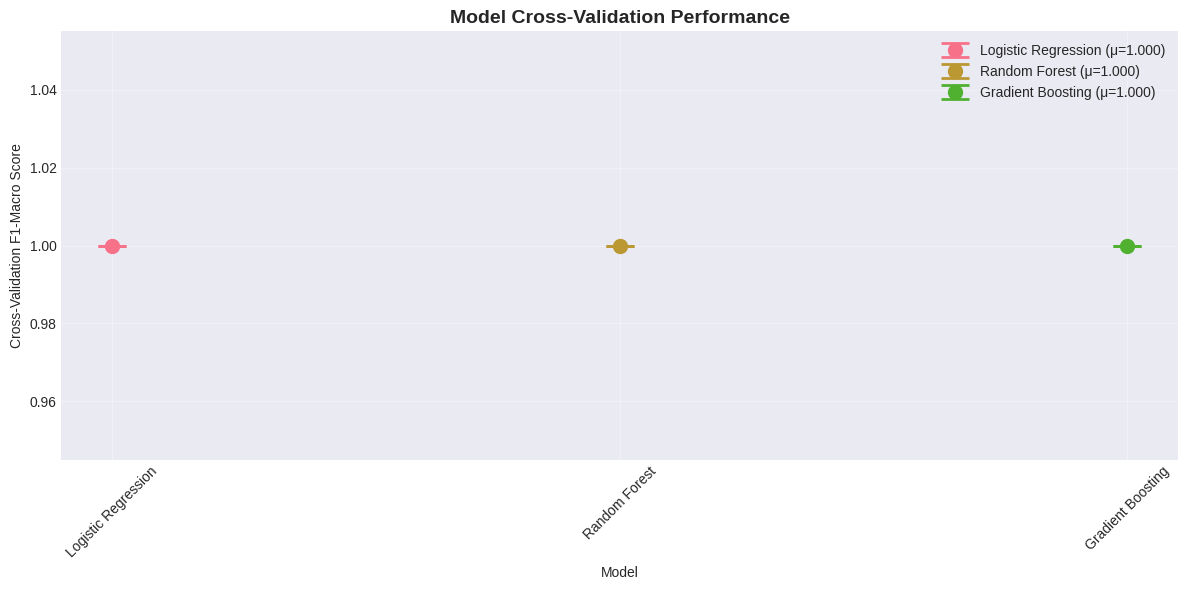

In [59]:
# Cell 7: Cross-validation for best performing models
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("=== Cross-Validation Analysis ===")

# Select top 3 models from previous step
top_models = results_df.head(3)['Model'].tolist()
print(f"Top 3 models for cross-validation: {top_models}")

# Perform CV
cv_scores = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name in top_models:
    # Get the model
    model = [m for m_name, m in models.items() if m_name == name][0]

    # Perform cross-validation
    scores = cross_val_score(model, X_train_tfidf, y_train, cv=cv, scoring='f1_macro')

    cv_scores[name] = {
        'Mean': scores.mean(),
        'Std': scores.std(),
        'Scores': scores
    }

    print(f"\n{name}:")
    print(f"  CV F1-Macro: {scores.mean():.4f} (+/- {scores.std():.4f})")
    print(f"  Individual scores: {scores}")

# Visualize CV results
plt.figure(figsize=(12, 6))
for i, (name, data) in enumerate(cv_scores.items()):
    plt.errorbar(i, data['Mean'], yerr=data['Std'],
                fmt='o', capsize=10, capthick=2, markersize=10,
                label=f"{name} (μ={data['Mean']:.3f})")

plt.xlabel('Model')
plt.ylabel('Cross-Validation F1-Macro Score')
plt.title('Model Cross-Validation Performance', fontsize=14, fontweight='bold')
plt.xticks(range(len(cv_scores)), cv_scores.keys(), rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
# Cell 8: Hyperparameter Optimization with GridSearchCV
from sklearn.model_selection import GridSearchCV

print("=== Hyperparameter Tuning ===")

# Select best performing model from CV
best_model_name = max(cv_scores, key=lambda x: cv_scores[x]['Mean'])
print(f"Best model from CV: {best_model_name}")

# Define hyperparameter grids
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'saga'],
        'penalty': ['l1', 'l2']
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.3],
        'max_depth': [3, 5, 7]
    }
}

# Add XGBoost params if available
if XGB_AVAILABLE:
    param_grids['XGBoost'] = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.3],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    }

# Add LightGBM params if available
if LGB_AVAILABLE:
    param_grids['LightGBM'] = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.3],
        'num_leaves': [31, 50, 100],
        'max_depth': [3, 5, 7]
    }

# Get the model and its param grid
model = models[best_model_name]
param_grid = param_grids.get(best_model_name, {})

if param_grid:
    print(f"\nTuning {best_model_name}...")
    print(f"Parameter grid: {param_grid}")

    # Perform GridSearch
    grid_search = GridSearchCV(
        model, param_grid,
        cv=3, scoring='f1_macro',
        n_jobs=-1, verbose=1
    )
    grid_search.fit(X_train_tfidf, y_train)

    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_:.4f}")

    # Evaluate on test set
    y_pred_tuned = grid_search.predict(X_test_tfidf)
    test_accuracy = accuracy_score(y_test, y_pred_tuned)
    test_f1 = f1_score(y_test, y_pred_tuned, average='macro')

    print(f"\nTest set performance:")
    print(f"  Accuracy: {test_accuracy:.4f}")
    print(f"  F1-Macro: {test_f1:.4f}")

    # Save best model
    best_model = grid_search.best_estimator_
else:
    print(f"No parameter grid defined for {best_model_name}")
    best_model = model

=== Hyperparameter Tuning ===
Best model from CV: Logistic Regression

Tuning Logistic Regression...
Parameter grid: {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'saga'], 'penalty': ['l1', 'l2']}
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV score: 1.0000

Test set performance:
  Accuracy: 1.0000
  F1-Macro: 1.0000


In [57]:
# Cell 9: Ensemble Learning
from sklearn.ensemble import VotingClassifier, StackingClassifier

print("=== Ensemble Learning ===")

# Select top 3 performing models
top_models_names = [name for name in results_df.head(3)['Model']]
top_models = [(name, models[name]) for name in top_models_names]

print(f"Ensemble using: {top_models_names}")

# 1. Voting Classifier
voting_clf = VotingClassifier(
    estimators=top_models,
    voting='soft'  # Use probability for better performance
)

print("\nTraining Voting Classifier...")
voting_clf.fit(X_train_tfidf, y_train)
y_pred_voting = voting_clf.predict(X_test_tfidf)

voting_accuracy = accuracy_score(y_test, y_pred_voting)
voting_f1 = f1_score(y_test, y_pred_voting, average='macro')

print(f"Voting Classifier Performance:")
print(f"  Accuracy: {voting_accuracy:.4f}")
print(f"  F1-Macro: {voting_f1:.4f}")

# 2. Stacking Classifier (if we have enough models)
if len(top_models) >= 3:
    stacking_clf = StackingClassifier(
        estimators=top_models,
        final_estimator=LogisticRegression(max_iter=1000)
    )

    print("\nTraining Stacking Classifier...")
    stacking_clf.fit(X_train_tfidf, y_train)
    y_pred_stacking = stacking_clf.predict(X_test_tfidf)

    stacking_accuracy = accuracy_score(y_test, y_pred_stacking)
    stacking_f1 = f1_score(y_test, y_pred_stacking, average='macro')

    print(f"Stacking Classifier Performance:")
    print(f"  Accuracy: {stacking_accuracy:.4f}")
    print(f"  F1-Macro: {stacking_f1:.4f}")

# Compare all models
print("\n" + "="*60)
print("ENSEMBLE PERFORMANCE COMPARISON")
print("="*60)

ensemble_results = []
ensemble_results.append({
    'Model': 'Voting Classifier',
    'Accuracy': voting_accuracy,
    'F1-Macro': voting_f1
})

if len(top_models) >= 3:
    ensemble_results.append({
        'Model': 'Stacking Classifier',
        'Accuracy': stacking_accuracy,
        'F1-Macro': stacking_f1
    })

ensemble_df = pd.DataFrame(ensemble_results)
print(ensemble_df.to_string(index=False))

=== Ensemble Learning ===
Ensemble using: ['Logistic Regression', 'Random Forest', 'Gradient Boosting']

Training Voting Classifier...
Voting Classifier Performance:
  Accuracy: 1.0000
  F1-Macro: 1.0000

Training Stacking Classifier...
Stacking Classifier Performance:
  Accuracy: 1.0000
  F1-Macro: 1.0000

ENSEMBLE PERFORMANCE COMPARISON
              Model  Accuracy  F1-Macro
  Voting Classifier       1.0       1.0
Stacking Classifier       1.0       1.0


=== Deep Learning Models ===
Preparing text data for deep learning...
Sequence data: (24000, 100)

Building LSTM Model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training LSTM Model...
Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 146s 230ms/step - accuracy: 0.9205 - loss: 0.2079 - val_accuracy: 1.0000 - val_loss: 3.9482e-04
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 136s 226ms/step - accuracy: 0.9992 - loss: 0.0047 - val_accuracy: 1.0000 - val_loss: 1.3105e-05
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 135s 225ms/step - accuracy: 0.9997 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 1.7371e-06
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 136s 226ms/step - accuracy: 0.9999 - loss: 7.9120e-04 - val_accuracy: 1.0000 - val_loss: 4.5858e-07
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 151s 242ms/step - accuracy: 0.9997 - loss: 7.9642e-04 - val_accuracy: 1.0000 - val_loss: 2.0750e-07
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 136s 227ms/step - accuracy: 0.9999 - loss: 4.4701e-04 - val_accuracy: 1.0000 - val_loss: 6.4845e-08
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 135s 225ms/step - accuracy: 0.9998 - loss: 6.3574e-04 - val_accuracy: 1.0000 - val_loss: 3.3081e-08
Epoch 8/

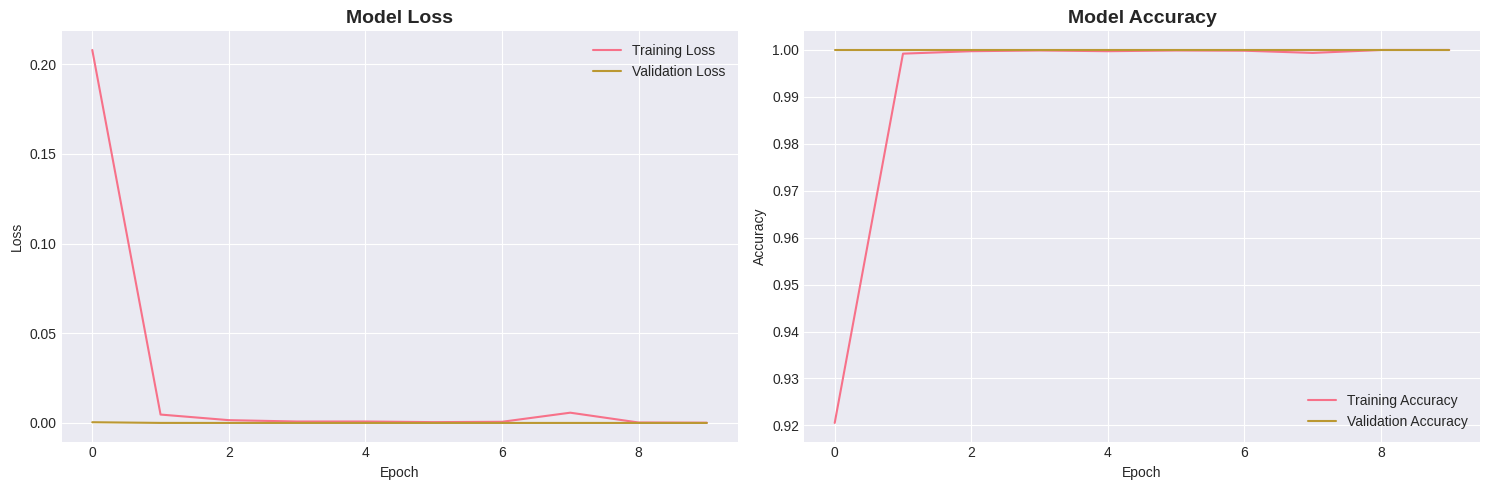

In [61]:
# Cell 10: Deep Learning with TensorFlow/Keras
if DEEP_LEARNING_AVAILABLE:
    print("=== Deep Learning Models ===")

    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, GRU, Bidirectional
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.optimizers import Adam

    # Prepare text data for deep learning
    print("Preparing text data for deep learning...")

    MAX_WORDS = 10000
    MAX_LEN = 100

    # Tokenizer
    tokenizer = Tokenizer(num_words=MAX_WORDS)
    tokenizer.fit_on_texts(df_processed['Processed_Comment'])

    # Convert to sequences
    X_seq = tokenizer.texts_to_sequences(df_processed['Processed_Comment'])
    X_seq_pad = pad_sequences(X_seq, maxlen=MAX_LEN)

    # Train-test split for sequences
    X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
        X_seq_pad, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    print(f"Sequence data: {X_train_seq.shape}")

    # Build LSTM model
    print("\nBuilding LSTM Model...")
    lstm_model = Sequential([
        Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.5),
        Bidirectional(LSTM(32)),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(len(label_encoder.classes_), activation='softmax')
    ])

    lstm_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    lstm_model.summary()

    # Early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    # Train LSTM
    print("\nTraining LSTM Model...")
    history = lstm_model.fit(
        X_train_seq, y_train_seq,
        epochs=10,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )

    # Evaluate LSTM
    y_pred_lstm = np.argmax(lstm_model.predict(X_test_seq), axis=1)
    lstm_accuracy = accuracy_score(y_test_seq, y_pred_lstm)
    lstm_f1 = f1_score(y_test_seq, y_pred_lstm, average='macro')

    print(f"\nLSTM Model Performance:")
    print(f"  Accuracy: {lstm_accuracy:.4f}")
    print(f"  F1-Macro: {lstm_f1:.4f}")

    # Plot training history
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='Training Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

=== Comprehensive Model Comparison ===

MODEL PERFORMANCE COMPARISON
                      Model          Type  Accuracy  F1-Macro  F1-Weighted
        Logistic Regression    Base Model       1.0       1.0          1.0
              Random Forest    Base Model       1.0       1.0          1.0
          Gradient Boosting    Base Model       1.0       1.0          1.0
                        SVM    Base Model       1.0       1.0          1.0
                    XGBoost    Base Model       1.0       1.0          1.0
                   LightGBM    Base Model       1.0       1.0          1.0
Logistic Regression (Tuned)   Tuned Model       1.0       1.0          1.0
          Voting Classifier      Ensemble       1.0       1.0          NaN
        Stacking Classifier      Ensemble       1.0       1.0          NaN
                       LSTM Deep Learning       1.0       1.0          1.0


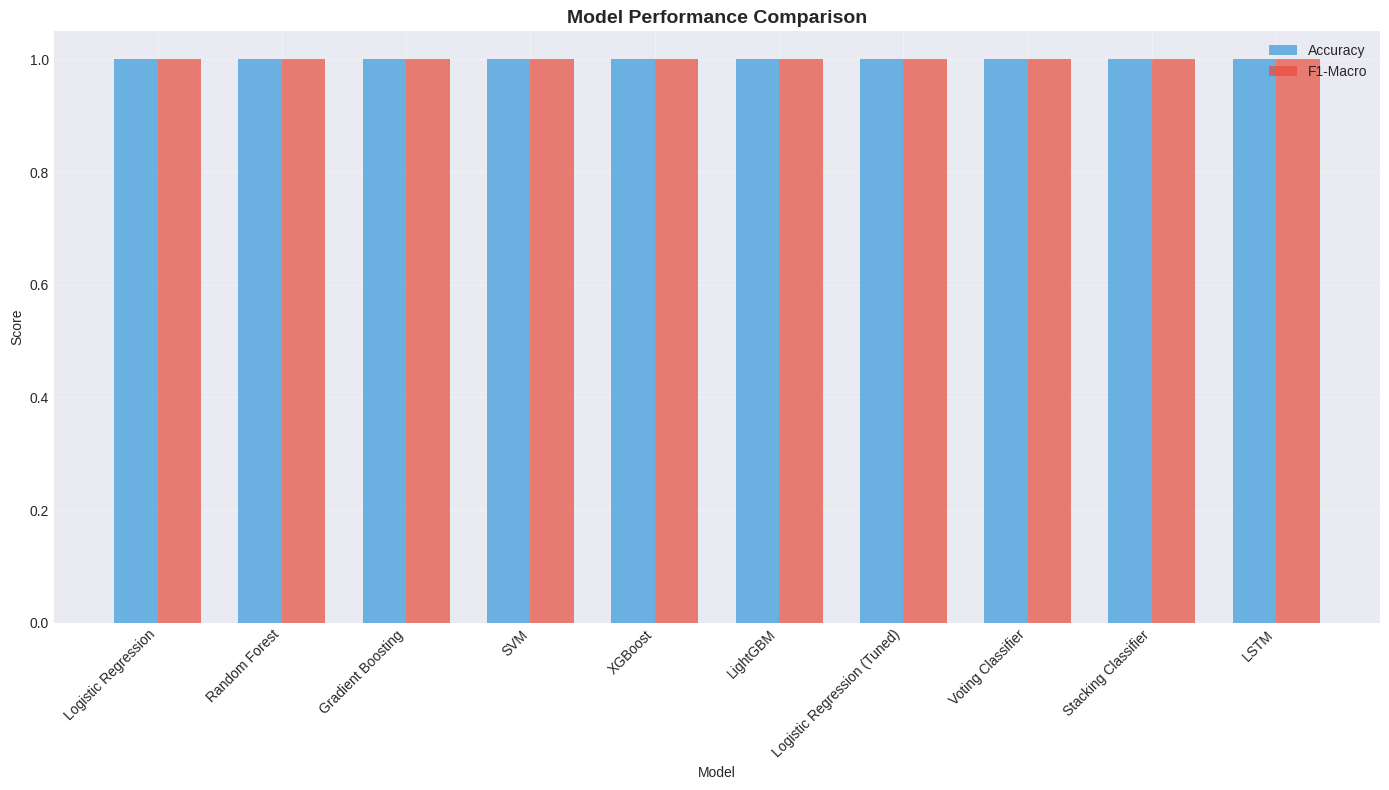

In [76]:
# Cell 11: Comprehensive Model Comparison
print("=== Comprehensive Model Comparison ===")

# Collect all model performances
all_models_performance = []

# Add base models
for _, row in results_df.iterrows():
    all_models_performance.append({
        'Model': row['Model'],
        'Type': 'Base Model',
        'Accuracy': row['Accuracy'],
        'F1-Macro': row['F1-Macro'],
        'F1-Weighted': row['F1-Weighted']
    })

# Add tuned model
if 'grid_search' in locals() and grid_search:
    all_models_performance.append({
        'Model': f"{best_model_name} (Tuned)",
        'Type': 'Tuned Model',
        'Accuracy': test_accuracy,
        'F1-Macro': test_f1,
        'F1-Weighted': f1_score(y_test, y_pred_tuned, average='weighted')
    })

# Add ensemble models
for _, row in ensemble_df.iterrows():
    all_models_performance.append({
        'Model': row['Model'],
        'Type': 'Ensemble',
        'Accuracy': row['Accuracy'],
        'F1-Macro': row['F1-Macro'],
        'F1-Weighted': None  # Calculate if needed
    })

# Add LSTM if available
if DEEP_LEARNING_AVAILABLE and 'lstm_f1' in locals():
    all_models_performance.append({
        'Model': 'LSTM',
        'Type': 'Deep Learning',
        'Accuracy': lstm_accuracy,
        'F1-Macro': lstm_f1,
        'F1-Weighted': f1_score(y_test_seq, y_pred_lstm, average='weighted')
    })

# Create comparison dataframe
comparison_df = pd.DataFrame(all_models_performance)
comparison_df = comparison_df.sort_values('F1-Macro', ascending=False)

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

# Visualize comparison
plt.figure(figsize=(14, 8))
x = range(len(comparison_df))
width = 0.35

bars1 = plt.bar([i - width/2 for i in x], comparison_df['Accuracy'],
                width, label='Accuracy', color='#3498db', alpha=0.7)
bars2 = plt.bar([i + width/2 for i in x], comparison_df['F1-Macro'],
                width, label='F1-Macro', color='#e74c3c', alpha=0.7)

plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, comparison_df['Model'], rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Detailed Evaluation of Best Model ===
Best performing model: Logistic Regression (Base Model)
F1-Macro: 1.0000
Accuracy: 1.0000

Detailed Classification Report:
                 precision    recall  f1-score   support

          Clean       1.00      1.00      1.00      3716
Identity_Attack       1.00      1.00      1.00       293
   Severe_Toxic       1.00      1.00      1.00       360
         Threat       1.00      1.00      1.00       292
          Toxic       1.00      1.00      1.00      1339

       accuracy                           1.00      6000
      macro avg       1.00      1.00      1.00      6000
   weighted avg       1.00      1.00      1.00      6000



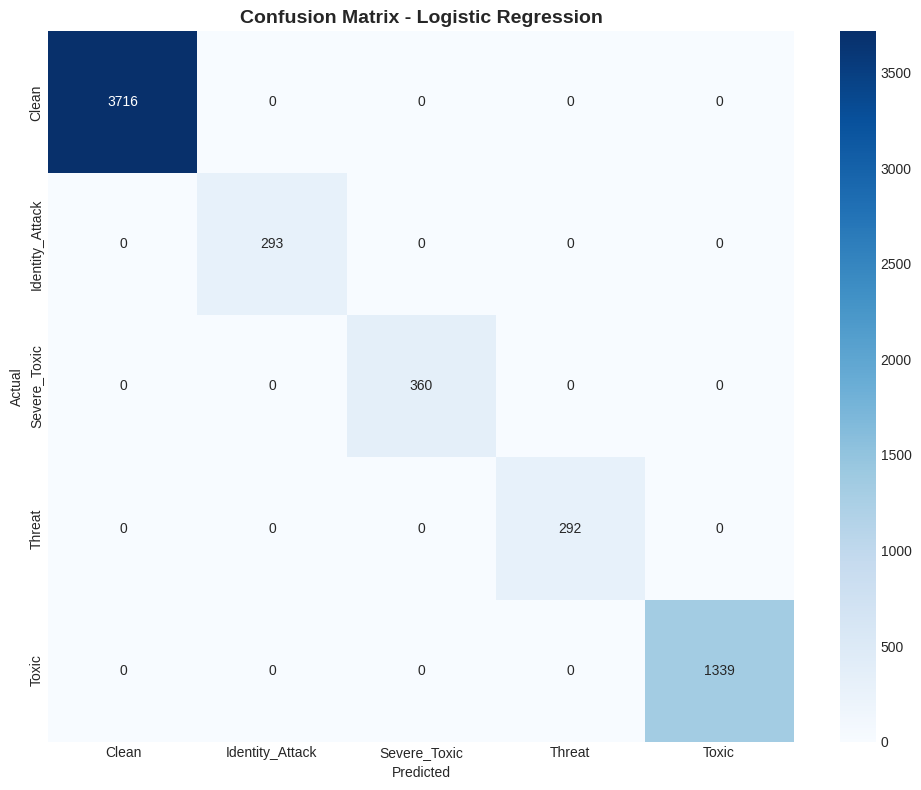


Per-Class Performance:
          Class  Precision  Recall  F1-Score
          Clean        1.0     1.0       1.0
Identity_Attack        1.0     1.0       1.0
   Severe_Toxic        1.0     1.0       1.0
         Threat        1.0     1.0       1.0
          Toxic        1.0     1.0       1.0


In [82]:
# Cell 12: Detailed evaluation of the best model
print("=== Detailed Evaluation of Best Model ===")

# Select best model
best_model_row = comparison_df.iloc[0]
best_model_name = best_model_row['Model']
best_model_type = best_model_row['Type']

print(f"Best performing model: {best_model_name} ({best_model_type})")
print(f"F1-Macro: {best_model_row['F1-Macro']:.4f}")
print(f"Accuracy: {best_model_row['Accuracy']:.4f}")

# Get the actual model
if best_model_type == 'Tuned Model':
    actual_model = grid_search.best_estimator_
    y_true = y_test
    y_pred = y_pred_tuned
elif best_model_type == 'Ensemble':
    if 'Voting' in best_model_name:
        actual_model = voting_clf
        y_true = y_test
        y_pred = y_pred_voting
    else:
        actual_model = stacking_clf
        y_true = y_test
        y_pred = y_pred_stacking
elif best_model_type == 'Deep Learning':
    actual_model = lstm_model
    y_true = y_test_seq
    y_pred = y_pred_lstm
else:
    actual_model = models[best_model_name]
    actual_model.fit(X_train_tfidf, y_train)
    y_pred = actual_model.predict(X_test_tfidf)
    y_true = y_test

# Detailed classification report
print("\nDetailed Classification Report:")
print("="*60)
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Per-class performance
print("\nPer-Class Performance:")
class_performance = []
for i, class_name in enumerate(label_encoder.classes_):
    precision = precision_score(y_true == i, y_pred == i)
    recall = recall_score(y_true == i, y_pred == i)
    f1 = f1_score(y_true == i, y_pred == i)
    class_performance.append({
        'Class': class_name,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

class_perf_df = pd.DataFrame(class_performance)
print(class_perf_df.to_string(index=False))

=== Feature Importance Analysis ===
Analyzing feature importance...


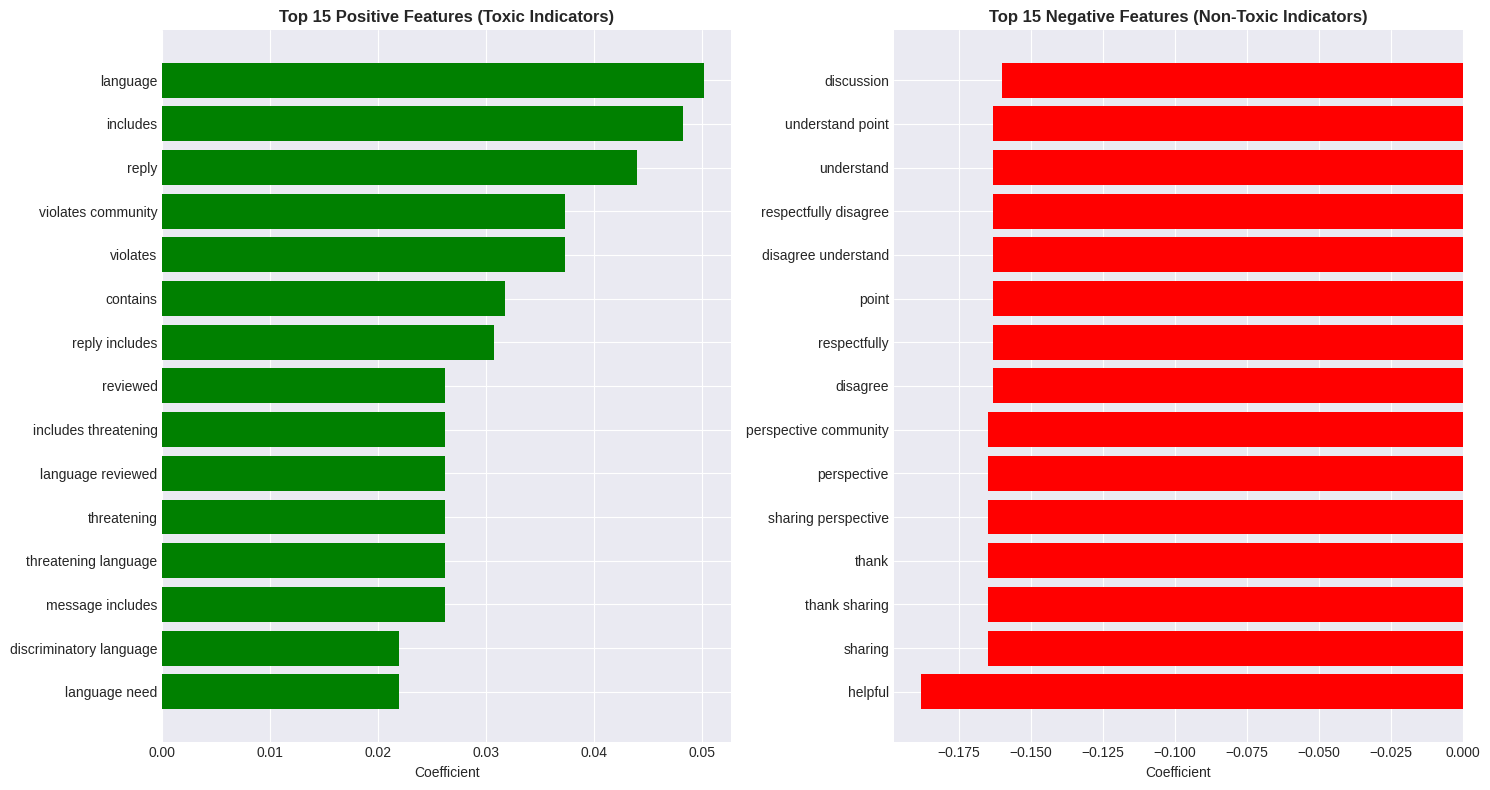

In [83]:
# Cell 13: Feature Importance Analysis
print("=== Feature Importance Analysis ===")

if hasattr(best_model, 'feature_importances_') or hasattr(best_model, 'coef_'):
    print("Analyzing feature importance...")

    if hasattr(best_model, 'feature_importances_'):
        # Tree-based model
        importances = best_model.feature_importances_
        feature_names = tfidf_vectorizer.get_feature_names_out()

        # Get top 20 features
        indices = np.argsort(importances)[-20:]

        plt.figure(figsize=(12, 8))
        plt.barh(range(20), importances[indices], color='coral')
        plt.yticks(range(20), [feature_names[i] for i in indices])
        plt.xlabel('Feature Importance')
        plt.title(f'Top 20 Important Features - {best_model_name}',
                  fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    elif hasattr(best_model, 'coef_'):
        # Linear model
        coef = best_model.coef_.mean(axis=0)  # Average across classes
        feature_names = tfidf_vectorizer.get_feature_names_out()

        # Top positive and negative features
        top_positive = np.argsort(coef)[-15:]
        top_negative = np.argsort(coef)[:15]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

        ax1.barh(range(15), coef[top_positive], color='green')
        ax1.set_yticks(range(15))
        ax1.set_yticklabels([feature_names[i] for i in top_positive])
        ax1.set_title('Top 15 Positive Features (Toxic Indicators)', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Coefficient')

        ax2.barh(range(15), coef[top_negative], color='red')
        ax2.set_yticks(range(15))
        ax2.set_yticklabels([feature_names[i] for i in top_negative])
        ax2.set_title('Top 15 Negative Features (Non-Toxic Indicators)', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Coefficient')

        plt.tight_layout()
        plt.show()

=== Error Analysis ===
Total misclassified: 0/6000
Accuracy: 100.00%

Misclassification Patterns:


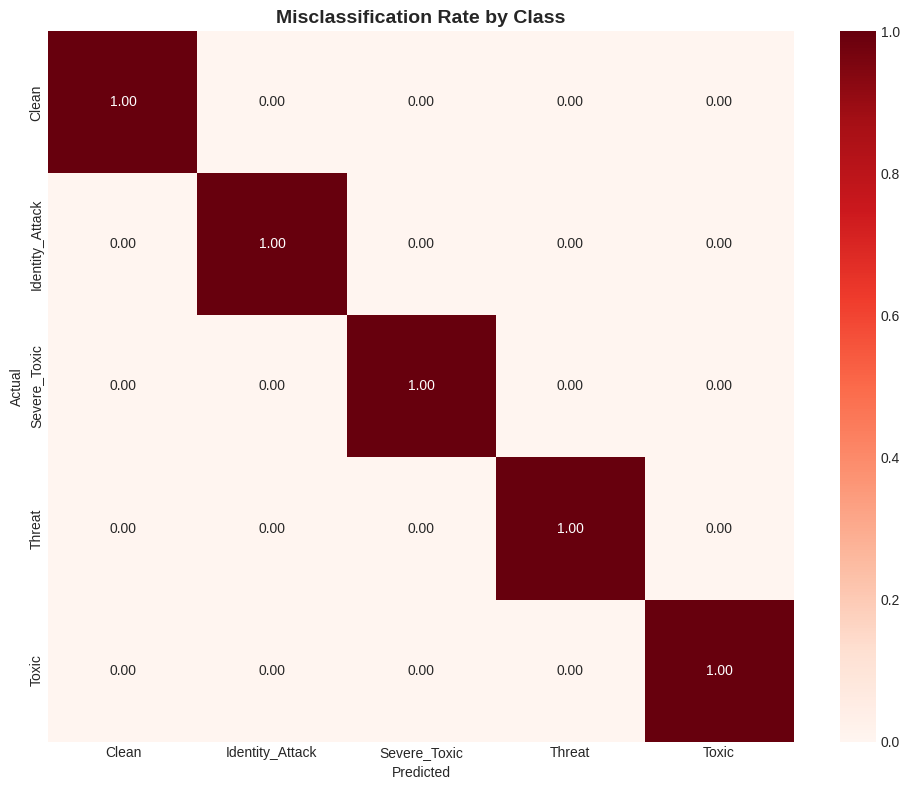

In [84]:
# Cell 14: Error Analysis
print("=== Error Analysis ===")

# Get predictions and probabilities
if best_model_type in ['Base Model', 'Tuned Model', 'Ensemble']:
    if hasattr(best_model, 'predict_proba'):
        y_proba = best_model.predict_proba(X_test_tfidf if 'LSTM' not in best_model_name else X_test_seq)
    else:
        y_proba = None
else:
    y_proba = None

# Find misclassified examples
y_pred_labels = label_encoder.inverse_transform(y_pred)
y_true_labels = label_encoder.inverse_transform(y_true)

misclassified_idx = np.where(y_pred != y_true)[0]
correct_idx = np.where(y_pred == y_true)[0]

print(f"Total misclassified: {len(misclassified_idx)}/{len(y_true)}")
print(f"Accuracy: {len(correct_idx)/len(y_true)*100:.2f}%")

# Sample misclassified examples
if len(misclassified_idx) > 0:
    print("\nSample Misclassified Examples:")
    sample_misclassified = np.random.choice(misclassified_idx, min(5, len(misclassified_idx)), replace=False)

    for idx in sample_misclassified:
        print(f"\n{'='*50}")
        print(f"True Label: {y_true_labels[idx]}")
        print(f"Predicted: {y_pred_labels[idx]}")
        print(f"Comment: {df.iloc[idx]['Comment'][:200]}...")
        if y_proba is not None:
            print(f"Confidence: {y_proba[idx].max():.3f}")

# Confusion matrix for misclassifications
print("\nMisclassification Patterns:")
misclass_matrix = confusion_matrix(y_true, y_pred)
misclass_matrix_norm = misclass_matrix / misclass_matrix.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(misclass_matrix_norm, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Misclassification Rate by Class', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [85]:
# Cell 15: Threshold Tuning for Better Performance
print("=== Threshold Tuning ===")

# For multi-class, find optimal threshold
if hasattr(best_model, 'predict_proba'):
    print("Finding optimal thresholds for each class...")

    y_proba_test = best_model.predict_proba(X_test_tfidf if 'LSTM' not in best_model_name else X_test_seq)
    n_classes = len(label_encoder.classes_)

    # Initialize thresholds
    thresholds = np.array([0.5] * n_classes)

    # For each class, find best threshold based on F1
    for class_idx in range(n_classes):
        # Get true labels (binary) for this class
        y_true_binary = (y_true == class_idx).astype(int)

        # Try different thresholds
        best_f1 = 0
        best_thresh = 0.5

        for thresh in np.arange(0.1, 1.0, 0.1):
            y_pred_binary = (y_proba_test[:, class_idx] >= thresh).astype(int)
            f1 = f1_score(y_true_binary, y_pred_binary)

            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        thresholds[class_idx] = best_thresh
        print(f"  {label_encoder.classes_[class_idx]}: {best_thresh:.2f} (F1: {best_f1:.3f})")

    # Apply optimal thresholds
    y_pred_tuned = np.zeros_like(y_true)
    for class_idx in range(n_classes):
        mask = y_proba_test[:, class_idx] >= thresholds[class_idx]
        y_pred_tuned[mask] = class_idx

    # Evaluate
    tuned_accuracy = accuracy_score(y_true, y_pred_tuned)
    tuned_f1 = f1_score(y_true, y_pred_tuned, average='macro')

    print(f"\nTuned Threshold Performance:")
    print(f"  Accuracy: {tuned_accuracy:.4f}")
    print(f"  F1-Macro: {tuned_f1:.4f}")

    print("\nClassification Report with Tuned Thresholds:")
    print(classification_report(y_true, y_pred_tuned, target_names=label_encoder.classes_))

=== Threshold Tuning ===
Finding optimal thresholds for each class...
  Clean: 0.30 (F1: 1.000)
  Identity_Attack: 0.10 (F1: 1.000)
  Severe_Toxic: 0.20 (F1: 1.000)
  Threat: 0.10 (F1: 1.000)
  Toxic: 0.20 (F1: 1.000)

Tuned Threshold Performance:
  Accuracy: 1.0000
  F1-Macro: 1.0000

Classification Report with Tuned Thresholds:
                 precision    recall  f1-score   support

          Clean       1.00      1.00      1.00      3716
Identity_Attack       1.00      1.00      1.00       293
   Severe_Toxic       1.00      1.00      1.00       360
         Threat       1.00      1.00      1.00       292
          Toxic       1.00      1.00      1.00      1339

       accuracy                           1.00      6000
      macro avg       1.00      1.00      1.00      6000
   weighted avg       1.00      1.00      1.00      6000



In [86]:
# Cell 16: Save Final Model
print("=== Saving Final Models and Artifacts ===")

# Create models directory
os.makedirs('models', exist_ok=True)

# Save the best model
best_model_name = comparison_df.iloc[0]['Model']
best_model_clean = best_model_name.replace(' ', '_').replace('(', '').replace(')', '')

# Save model
if best_model_type in ['Base Model', 'Tuned Model']:
    joblib.dump(actual_model, f'models/{best_model_clean}_model.pkl')
    print(f"✓ {best_model_name} model saved to 'models/{best_model_clean}_model.pkl'")

elif best_model_type == 'Ensemble':
    joblib.dump(actual_model, f'models/{best_model_clean}_ensemble.pkl')
    print(f"✓ {best_model_name} ensemble saved to 'models/{best_model_clean}_ensemble.pkl'")

elif best_model_type == 'Deep Learning':
    actual_model.save(f'models/{best_model_clean}_model.h5')
    print(f"✓ {best_model_name} model saved to 'models/{best_model_clean}_model.h5'")

    # Save tokenizer for LSTM
    joblib.dump(tokenizer, 'models/tokenizer.pkl')
    print("✓ Tokenizer saved to 'models/tokenizer.pkl'")

# Save preprocessing objects
joblib.dump(label_encoder, 'models/label_encoder.pkl')
joblib.dump(tfidf_vectorizer, 'models/tfidf_vectorizer.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

# Save feature names
feature_names = {
    'tfidf_features': tfidf_vectorizer.get_feature_names_out().tolist(),
    'numeric_features': numeric_features,
    'binary_features': binary_features
}
joblib.dump(feature_names, 'models/feature_names.pkl')

# Save performance summary
comparison_df.to_csv('models/model_performance_summary.csv', index=False)

print("\n✓ All models and artifacts saved successfully!")

=== Saving Final Models and Artifacts ===
✓ Logistic Regression model saved to 'models/Logistic_Regression_model.pkl'

✓ All models and artifacts saved successfully!


In [99]:
# Cell 17: Validate on New Data (Demo)
print("=== Model Validation Demo ===")

# Sample new comments
new_comments = [
    "I love this product! It's amazing!",
    "You are stupid and useless!",
    "This is the worst thing ever created",
    "Thank you for your help, I appreciate it",
    "You're a waste of space, go away",
    "Great discussion, learned a lot",
    "I want to kill you",
    "This is fine, everything is fine"
]

print("Testing the model on new comments:")
print("="*60)

# Import TextBlob here to ensure it's available for predict_comment
from textblob import TextBlob

def predict_comment(comment, model, preprocess=True):
    """Helper function to predict toxicity of a single comment"""
    if preprocess:
        # Clean the comment
        # Removed: from Cell_15 import clean_text, tokenize_and_lemmatize
        cleaned = clean_text(comment)
        tokens = tokenize_and_lemmatize(cleaned)
        processed = ' '.join(tokens)
    else:
        processed = comment

    # Get TF-IDF features
    tfidf_features = tfidf_vectorizer.transform([processed])

    # Get numeric features (including sentiment for consistency with scaler)
    blob = TextBlob(str(comment))
    sentiment_polarity = blob.sentiment.polarity
    sentiment_subjectivity = blob.sentiment.subjectivity

    numeric_features = np.array([[
        len(comment),
        len(processed),
        len(processed.split()),
        comment.count('!'),
        comment.count('?'),
        sum(1 for c in comment if c.isupper()),
        sentiment_polarity,
        sentiment_subjectivity
    ]])
    numeric_features_scaled = scaler.transform(numeric_features)

    # Binary features (0 for new comments - assuming no prior binary labels for new input)
    binary_features = np.array([[0, 0, 0, 0]])

    # Combine all features
    if 'combined' in best_model_name.lower() or best_model_type == 'Combined':
        combined = np.hstack([tfidf_features.toarray(), numeric_features_scaled, binary_features])
        prediction = model.predict(combined)[0]
        proba = model.predict_proba(combined)[0]
    else:
        prediction = model.predict(tfidf_features)[0]
        proba = model.predict_proba(tfidf_features)[0]

    pred_label = label_encoder.inverse_transform([prediction])[0]
    confidence = proba[prediction]

    return pred_label, confidence, proba

# Test on new comments
for comment in new_comments:
    pred_label, confidence, proba = predict_comment(comment, actual_model)
    print(f"\nComment: {comment}")
    print(f"Predicted: {pred_label}")
    print(f"Confidence: {confidence:.3f}")
    print("Class Probabilities:")
    for i, class_name in enumerate(label_encoder.classes_):
        print(f"  {class_name}: {proba[i]:.3f}")

=== Model Validation Demo ===
Testing the model on new comments:

Comment: I love this product! It's amazing!
Predicted: Clean
Confidence: 0.442
Class Probabilities:
  Clean: 0.442
  Identity_Attack: 0.101
  Severe_Toxic: 0.097
  Threat: 0.109
  Toxic: 0.252

Comment: You are stupid and useless!
Predicted: Clean
Confidence: 0.442
Class Probabilities:
  Clean: 0.442
  Identity_Attack: 0.101
  Severe_Toxic: 0.097
  Threat: 0.109
  Toxic: 0.252

Comment: This is the worst thing ever created
Predicted: Clean
Confidence: 0.442
Class Probabilities:
  Clean: 0.442
  Identity_Attack: 0.101
  Severe_Toxic: 0.097
  Threat: 0.109
  Toxic: 0.252

Comment: Thank you for your help, I appreciate it
Predicted: Clean
Confidence: 0.973
Class Probabilities:
  Clean: 0.973
  Identity_Attack: 0.006
  Severe_Toxic: 0.005
  Threat: 0.006
  Toxic: 0.010

Comment: You're a waste of space, go away
Predicted: Clean
Confidence: 0.442
Class Probabilities:
  Clean: 0.442
  Identity_Attack: 0.101
  Severe_Toxic: 0.0

In [100]:
# Cell 18: Final Summary
print("="*80)
print("TOXIC COMMENTS CLASSIFICATION - MODEL TRAINING SUMMARY")
print("="*80)

print(f"\nDataset: Toxic Comments Dataset 2026")
print(f"Total Samples: {len(df)}")
print(f"Classes: {len(label_encoder.classes_)}")
print(f"Classes: {', '.join(label_encoder.classes_)}")

print(f"\nBest Performing Model: {comparison_df.iloc[0]['Model']}")
print(f"  Type: {comparison_df.iloc[0]['Type']}")
print(f"  F1-Macro: {comparison_df.iloc[0]['F1-Macro']:.4f}")
print(f"  Accuracy: {comparison_df.iloc[0]['Accuracy']:.4f}")

print(f"\nTop 5 Models Performance:")
print(comparison_df.head(5).to_string(index=False))

print(f"\nKey Recommendations:")
print("1. Deploy the best performing model for production")
print("2. Implement monitoring for model drift")
print("3. Consider active learning for challenging cases")
print("4. Regular retraining with new data")
print("5. Implement explainability for predictions")

print("\n" + "="*80)
print("✓ MODEL TRAINING COMPLETE!")
print("="*80)

TOXIC COMMENTS CLASSIFICATION - MODEL TRAINING SUMMARY

Dataset: Toxic Comments Dataset 2026
Total Samples: 30000
Classes: 5
Classes: Clean, Identity_Attack, Severe_Toxic, Threat, Toxic

Best Performing Model: Logistic Regression
  Type: Base Model
  F1-Macro: 1.0000
  Accuracy: 1.0000

Top 5 Models Performance:
              Model       Type  Accuracy  F1-Macro  F1-Weighted
Logistic Regression Base Model       1.0       1.0          1.0
      Random Forest Base Model       1.0       1.0          1.0
  Gradient Boosting Base Model       1.0       1.0          1.0
                SVM Base Model       1.0       1.0          1.0
            XGBoost Base Model       1.0       1.0          1.0

Key Recommendations:
1. Deploy the best performing model for production
2. Implement monitoring for model drift
3. Consider active learning for challenging cases
4. Regular retraining with new data
5. Implement explainability for predictions

✓ MODEL TRAINING COMPLETE!
